In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../yaleemmlc_admissionprediction_triage.csv", index_col=0, on_bad_lines='skip')
TARGET = "esi"

print(f"Dataset loaded successfully! Total records: {df.shape[0]}")

Dataset loaded successfully! Total records: 93243


/tmp/ipykernel_22372/246155827.py:8: DtypeWarning: Columns (29,33,55,131,170,189) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../yaleemmlc_admissionprediction_triage.csv", index_col=0, on_bad_lines='skip')


In [8]:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

PLAUSIBLE = {
    "age": (0, 120), "esi": (1, 5), "triage_vital_hr": (20, 250),
    "triage_vital_sbp": (50, 300), "triage_vital_dbp": (20, 200),
    "triage_vital_rr": (4, 60), "triage_vital_o2": (50, 100),
    "triage_vital_temp": (86, 110), "triage_glucose": (20, 800)
}

df_clean = df[df[TARGET].notna()].copy()
for col in VITALS + ["age"]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
for col, (low, high) in PLAUSIBLE.items():
    if col in df_clean.columns:
        df_clean.loc[(df_clean[col] < low) | (df_clean[col] > high), col] = np.nan

In [9]:
# Check if oxygen missingness is related to a patient's true acuity level
df['o2_missing'] = df['triage_vital_o2'].isna()
print(pd.crosstab(df['o2_missing'], df[TARGET], normalize='index') * 100)

esi              0.0       1.0         2.0        3.0        4.0       5.0
o2_missing                                                                
False       0.001072  0.137277   32.557217  48.995088  16.092533  2.216812
True        0.000000  0.000000  100.000000   0.000000   0.000000  0.000000


In [11]:
# Calculate how many of the 200 chief complaints appear in fewer than 0.5% of patients
cc_cols = [c for c in df.columns if c.startswith('cc_')]

# Convert all chief complaint columns to numeric, forcing stray text strings into NaN
df_cc_numeric = df[cc_cols].apply(pd.to_numeric, errors='coerce')

# Calculate column averages safely, ignoring missing/bad rows
sparse_count = (df_cc_numeric.mean() < 0.005).sum()

print(f"Out of {len(cc_cols)} chief complaints, {sparse_count} columns are highly sparse (<0.5% prevalence).")

Out of 200 chief complaints, 151 columns are highly sparse (<0.5% prevalence).


In [12]:
# Show which vitals correlate best/worst with the target ESI score
print("Vitals Correlation Matrix with ESI:")
print(df_clean[VITALS + [TARGET]].corr()[TARGET])

# Check how chest pain skews urgency levels
print("\nChest Pain Urgency Cross-tabulation:")
print(pd.crosstab(df_clean['cc_chestpain'], df_clean[TARGET], normalize='index') * 100)

Vitals Correlation Matrix with ESI:
triage_vital_hr     -0.094059
triage_vital_sbp    -0.001107
triage_vital_dbp     0.045228
triage_vital_rr     -0.097994
triage_vital_o2      0.178240
triage_vital_temp   -0.022313
triage_glucose      -0.076472
esi                  1.000000
Name: esi, dtype: float64

Chest Pain Urgency Cross-tabulation:
esi                1.0        2.0         3.0        4.0       5.0
cc_chestpain                                                      
0.0           0.140238  30.659233   49.649980  17.175700  2.374849
1.0           0.096138  59.012979   39.881429   0.993431  0.016023
2.0           0.000000   0.000000  100.000000   0.000000  0.000000


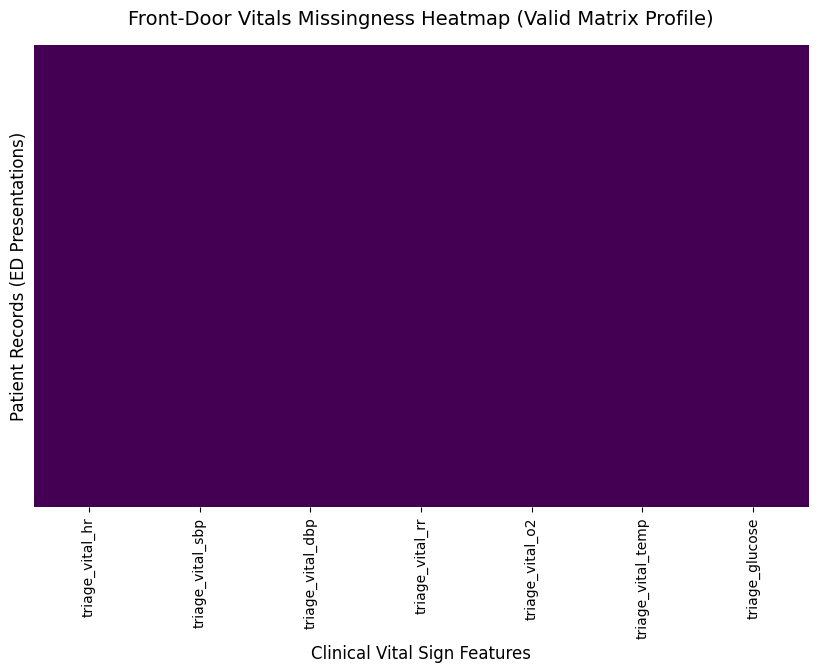

In [24]:

# Ensure the folder exists locally
os.makedirs("../figs", exist_ok=True)

# 1. Clean out empty rows where vital statistics are completely unparsed strings
vitals_subset = df_clean[VITALS].apply(pd.to_numeric, errors='coerce')

# 2. Plot the Heatmap
plt.figure(figsize=(10, 6))
# Using sample(2000) or a slice helps render it beautifully and quickly
sns.heatmap(vitals_subset.isna(), cbar=False, cmap="viridis", yticklabels=False)

plt.title("Front-Door Vitals Missingness Heatmap (Valid Matrix Profile)", fontsize=14, pad=15)
plt.xlabel("Clinical Vital Sign Features", fontsize=12)
plt.ylabel("Patient Records (ED Presentations)", fontsize=12)

# Save and show
plt.savefig("../figs/missingness_heatmap.png", bbox_inches='tight', dpi=300)
plt.show()




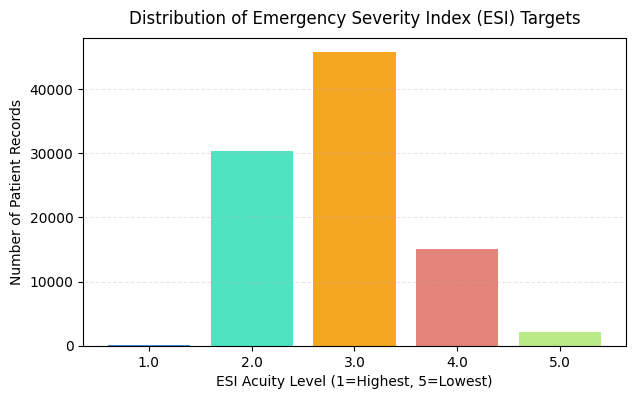

In [26]:
# 2. ESI Distribution Target Chart
plt.figure(figsize=(7, 4))

# Compute counts
esi_counts = df_clean['esi'].value_counts().sort_index()

# Plot directly as a clean bar chart
plt.bar(esi_counts.index.astype(str), esi_counts.values, color=['#4A90E2', '#50E3C2', '#F5A623', '#E2847A', '#B8E986'])

plt.title("Distribution of Emergency Severity Index (ESI) Targets", fontsize=12, pad=10)
plt.xlabel("ESI Acuity Level (1=Highest, 5=Lowest)", fontsize=10)
plt.ylabel("Number of Patient Records", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Save and show
plt.savefig("../figs/esi_distribution.png", bbox_inches='tight', dpi=300)
plt.show()


Dashboard graphics successfully saved to the /figs directory!


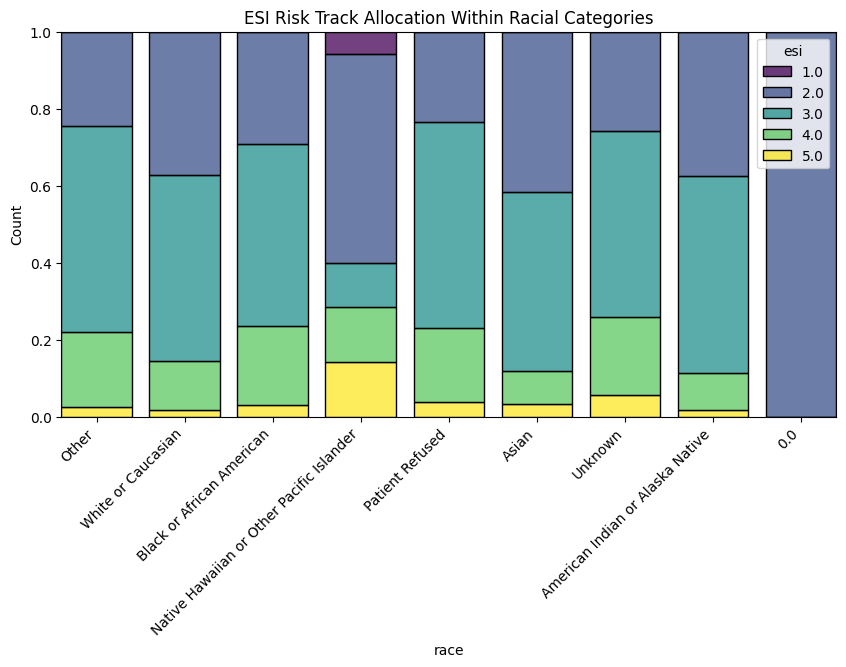

In [28]:
# 3. Clinical Equity Bias Check Plot
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='race', hue='esi', multiple='fill', shrink=0.8, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("ESI Risk Track Allocation Within Racial Categories")
plt.savefig("../figs/equity_race_bias.png", bbox_inches='tight')


print("Dashboard graphics successfully saved to the /figs directory!")